# Variability Mode API Test Notebook

This notebook demonstrates the variability mode standard API using CMIP5 demo data.

## Features Tested:
- Basic EOF analysis for atmospheric modes (NAO, NAM)
- SST-based modes (PDO, NPGO)
- With and without reference data (metrics)
- **New: `remove_domain_mean` parameter** (detrending)
- **New: `land_mask` parameter** (for SST modes)
- Different season options
- Time subsetting

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Import variability mode API functions
from pcmdi_metrics.variability_mode import NAO, NAM, SAM, PDO, NPGO

print("Imports successful!")

Imports successful!


## Setup: Define Data Paths

In [2]:
# Base directory for demo data
base_dir = Path("../../../doc/jupyter/Demo/demo_data")

# Model data paths
model_psl_path = base_dir / "CMIP5_demo_data" / "psl_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc"
model_ts_path = base_dir / "CMIP5_demo_data" / "ts_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc"
model_sftlf_path = base_dir / "CMIP5_demo_data" / "sftlf_fx_ACCESS1-0_amip_r0i0p0.nc"

# Reference data paths
ref_psl_path = base_dir / "obs4MIPs_PCMDI_monthly" / "NOAA-ESRL-PSD" / "20CR" / "mon" / "psl" / "gn" / "v20210727" / "psl_mon_20CR_PCMDI_gn_187101-201212.nc"
ref_ts_path = base_dir / "obs4MIPs_PCMDI_monthly" / "MOHC" / "HadISST-1-1" / "mon" / "ts" / "gn" / "v20260416" / "ts_mon_HadISST-1-1_PCMDI_gn_187001-202501.nc"

# Verify files exist
for path in [model_psl_path, model_ts_path, model_sftlf_path, ref_psl_path, ref_ts_path]:
    if path.exists():
        print(f"✓ {path.name}")
    else:
        print(f"✗ MISSING: {path}")

✓ psl_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc
✓ ts_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc
✓ sftlf_fx_ACCESS1-0_amip_r0i0p0.nc
✓ psl_mon_20CR_PCMDI_gn_187101-201212.nc
✓ ts_mon_HadISST-1-1_PCMDI_gn_187001-202501.nc


## Load Data

In [3]:
# Load model data
model_psl = xr.open_dataset(model_psl_path)
model_ts = xr.open_dataset(model_ts_path)
model_sftlf = xr.open_dataset(model_sftlf_path)

# Load reference data
ref_psl = xr.open_dataset(ref_psl_path)
ref_ts = xr.open_dataset(ref_ts_path)

print("Model PSL shape:", model_psl['psl'].shape)
print("Model TS shape:", model_ts['ts'].shape)
print("Land fraction shape:", model_sftlf['sftlf'].shape)
print("\nReference PSL shape:", ref_psl['psl'].shape)
print("Reference TS shape:", ref_ts['ts'].shape)

Model PSL shape: (1872, 145, 192)
Model TS shape: (1872, 145, 192)
Land fraction shape: (145, 192)

Reference PSL shape: (1704, 91, 180)
Reference TS shape: (1861, 180, 360)


## Test 1: Basic NAO (No Reference Data)

Compute NAO using default settings:
- All 4 seasons (DJF, MAM, JJA, SON)
- Default `remove_domain_mean=True`
- No reference data (diagnostics only)

In [10]:
print("Computing NAO (basic)...")
nao_results = NAO(
    model_psl, 
    data_var='psl', 
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa)
    start_year=1950,
    end_year=2000
)

# Display results
for season in ['DJF', 'MAM', 'JJA', 'SON']:
    frac = nao_results[season]['diagnostics']['frac']
    stdv = nao_results[season]['diagnostics']['stdv_pc']
    print(f"NAO {season}: variance fraction = {frac:.4f}, PC stdv = {stdv:.2f}")

Computing NAO (basic)...
Converting units by  divide 100.0
NAO DJF: variance fraction = 0.3199, PC stdv = 1.51
NAO MAM: variance fraction = 0.4237, PC stdv = 1.50
NAO JJA: variance fraction = 0.3111, PC stdv = 0.71
NAO SON: variance fraction = 0.3276, PC stdv = 1.06


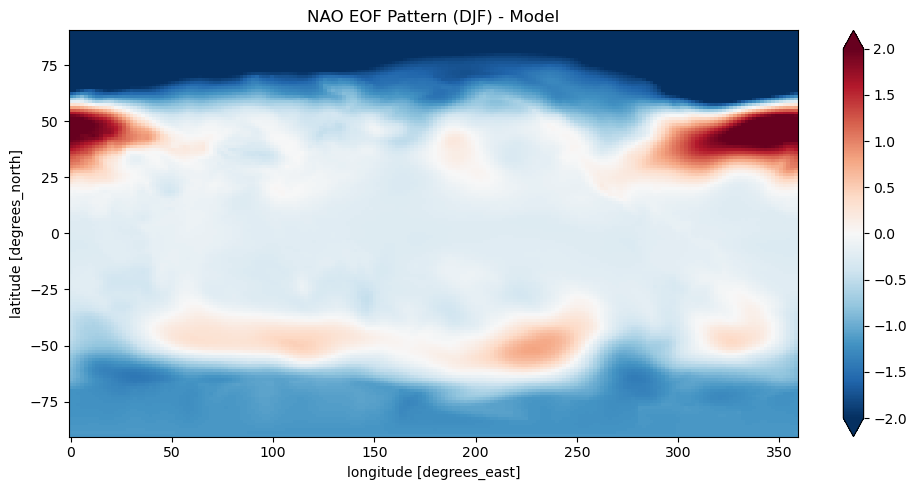

In [13]:
# Plot NAO EOF pattern for DJF
fig, ax = plt.subplots(figsize=(10, 5))
eof_pattern = nao_results['DJF']['diagnostics']['eof_pattern']
eof_pattern.plot(ax=ax, cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_title('NAO EOF Pattern (DJF) - Model')
plt.tight_layout()
plt.show()

## Test 2: NAM with Reference Data (Metrics)

Compute NAM with reference data to get comparison metrics.

In [14]:
print("Computing NAM with reference data...")
nam_results = NAM(
    model_psl,
    data_var='psl',
    reference_ds=ref_psl,
    seasons=['DJF', 'JJA'],  # Only winter and summer
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa)
    start_year=1950,
    end_year=2000
)

# Display diagnostics and metrics
for season in ['DJF', 'JJA']:
    print(f"\nNAM {season} Diagnostics:")
    frac = nam_results[season]['diagnostics']['frac']
    stdv = nam_results[season]['diagnostics']['stdv_pc']
    print(f"  Variance fraction: {frac:.4f}")
    print(f"  PC stdv: {stdv:.2f}")
    
    print(f"\nNAM {season} Metrics:")
    metrics = nam_results[season]['metrics']
    print(f"  Correlation: {metrics['cor']:.4f}")
    print(f"  RMS error: {metrics['rms']:.4f}")
    print(f"  Bias: {metrics['bias']:.4f}")

Computing NAM with reference data...
Converting units by  divide 100.0

NAM DJF Diagnostics:
  Variance fraction: 0.2002
  PC stdv: 1.19

NAM DJF Metrics:
  Correlation: 0.3871
  RMS error: 159.5024
  Bias: -0.0033

NAM JJA Diagnostics:
  Variance fraction: 0.2088
  PC stdv: 0.62

NAM JJA Metrics:
  Correlation: 0.6570
  RMS error: 58.2578
  Bias: 0.0007


## Test 3: Testing `remove_domain_mean` Parameter

Compare results with and without domain mean removal (detrending).

In [15]:
print("Testing remove_domain_mean parameter...\n")

# With domain mean removal (default)
nam_with_detrend = NAM(
    model_psl,
    data_var='psl',
    seasons=['DJF'],
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa)
    remove_domain_mean=True
)

# Without domain mean removal
nam_no_detrend = NAM(
    model_psl,
    data_var='psl',
    seasons=['DJF'],
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa)
    remove_domain_mean=False
)

print("NAM DJF with remove_domain_mean=True:")
print(f"  Variance fraction: {nam_with_detrend['DJF']['diagnostics']['frac']:.4f}")
print(f"  PC stdv: {nam_with_detrend['DJF']['diagnostics']['stdv_pc']:.2f}")

print("\nNAM DJF with remove_domain_mean=False:")
print(f"  Variance fraction: {nam_no_detrend['DJF']['diagnostics']['frac']:.4f}")
print(f"  PC stdv: {nam_no_detrend['DJF']['diagnostics']['stdv_pc']:.2f}")

print("\nNote: Results differ because removing domain mean focuses on spatial patterns")
print("rather than domain-average trends. Default (True) is recommended.")

Testing remove_domain_mean parameter...

Converting units by  divide 100.0
Converting units by  divide 100.0
NAM DJF with remove_domain_mean=True:
  Variance fraction: 0.2036
  PC stdv: 1.21

NAM DJF with remove_domain_mean=False:
  Variance fraction: 0.1986
  PC stdv: 1.21

Note: Results differ because removing domain mean focuses on spatial patterns
rather than domain-average trends. Default (True) is recommended.


## Test 4: PDO with Monthly Analysis

Compute PDO using SST data with default monthly analysis.

In [8]:
print("Computing PDO (monthly analysis)...")
pdo_results = PDO(
    model_ts,
    data_var='ts',
    start_year=1950,
    end_year=2000
)

# Display results
frac = pdo_results['monthly']['diagnostics']['frac']
stdv = pdo_results['monthly']['diagnostics']['stdv_pc']
print(f"\nPDO (monthly): variance fraction = {frac:.4f}, PC stdv = {stdv:.2f}")

Computing PDO (monthly analysis)...

PDO (monthly): variance fraction = 0.1683, PC stdv = 0.65


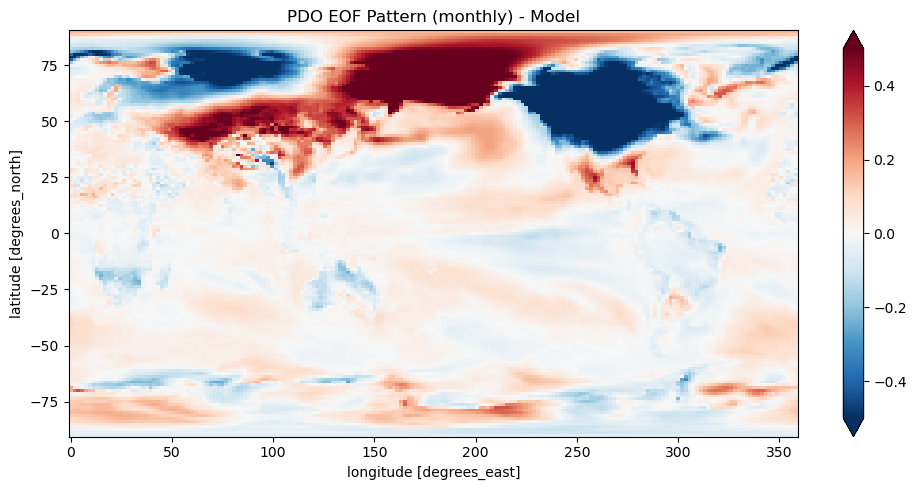

In [9]:
# Plot PDO EOF pattern
fig, ax = plt.subplots(figsize=(10, 5))
eof_pattern = pdo_results['monthly']['diagnostics']['eof_pattern']
eof_pattern.plot(ax=ax, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_title('PDO EOF Pattern (monthly) - Model')
plt.tight_layout()
plt.show()

## Test 5: PDO with Land Masking

Compute PDO with land regions masked out, using both:
1. Automatic land mask generation
2. Explicit land fraction data

In [10]:
print("Testing land_mask parameter...\n")

# Without land masking (default)
pdo_no_mask = PDO(
    model_ts,
    data_var='ts',
    seasons=['monthly'],
    land_mask=False,
    start_year=1950,
    end_year=2000
)

# With automatic land mask generation
pdo_auto_mask = PDO(
    model_ts,
    data_var='ts',
    seasons=['monthly'],
    land_mask=True,
    start_year=1950,
    end_year=2000
)

# With explicit land fraction data
pdo_explicit_mask = PDO(
    model_ts,
    data_var='ts',
    seasons=['monthly'],
    land_mask=True,
    landfrac_ds=model_sftlf,
    start_year=1950,
    end_year=2000
)

print("PDO (no land mask):")
print(f"  Variance fraction: {pdo_no_mask['monthly']['diagnostics']['frac']:.4f}")

print("\nPDO (automatic land mask):")
print(f"  Variance fraction: {pdo_auto_mask['monthly']['diagnostics']['frac']:.4f}")

print("\nPDO (explicit land fraction):")
print(f"  Variance fraction: {pdo_explicit_mask['monthly']['diagnostics']['frac']:.4f}")

print("\nNote: Land masking focuses analysis on ocean regions only,")
print("which is appropriate for SST-based modes like PDO, NPGO, and AMO.")

Testing land_mask parameter...



/Users/lee1043/miniforge3/envs/pmp_devel_20260331/lib/python3.12/site-packages/pcmdi_metrics/utils/land_sea_mask.py:218: UserWarning: landfrac is not provided thus generated using the 'create_land_sea_mask' function
  warnings.warn(


PDO (no land mask):
  Variance fraction: 0.1683

PDO (automatic land mask):
  Variance fraction: 0.1567

PDO (explicit land fraction):
  Variance fraction: 0.1608

Note: Land masking focuses analysis on ocean regions only,
which is appropriate for SST-based modes like PDO, NPGO, and AMO.


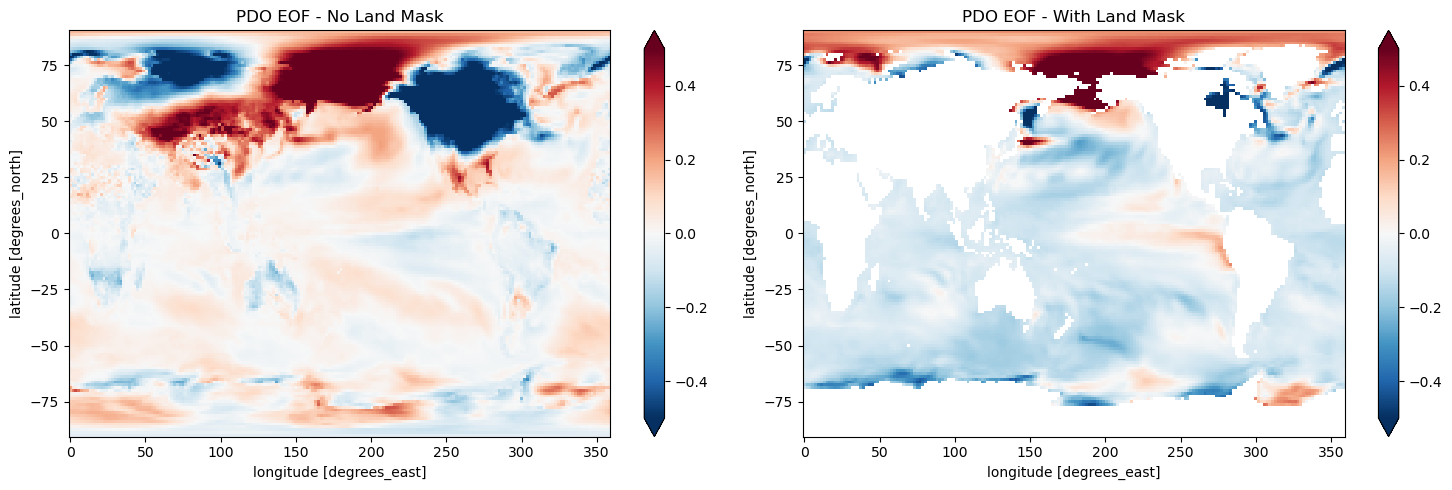

Notice: Land regions are masked (white/NaN) in the right panel.


In [11]:
# Compare EOF patterns with and without land masking
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Without land mask
eof_no_mask = pdo_no_mask['monthly']['diagnostics']['eof_pattern']
eof_no_mask.plot(ax=axes[0], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0].set_title('PDO EOF - No Land Mask')

# With land mask
eof_with_mask = pdo_explicit_mask['monthly']['diagnostics']['eof_pattern']
eof_with_mask.plot(ax=axes[1], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1].set_title('PDO EOF - With Land Mask')

plt.tight_layout()
plt.show()

print("Notice: Land regions are masked (white/NaN) in the right panel.")

## Test 6: NPGO (2nd EOF) with Land Masking

In [12]:
print("Computing NPGO (2nd EOF of SST) with land masking...")
npgo_results = NPGO(
    model_ts,
    data_var='ts',
    land_mask=True,
    landfrac_ds=model_sftlf,
    start_year=1950,
    end_year=2000
)

frac = npgo_results['monthly']['diagnostics']['frac']
stdv = npgo_results['monthly']['diagnostics']['stdv_pc']
print(f"\nNPGO (monthly): variance fraction = {frac:.4f}, PC stdv = {stdv:.2f}")
print("Note: NPGO is the 2nd EOF, while PDO is the 1st EOF")

Computing NPGO (2nd EOF of SST) with land masking...

NPGO (monthly): variance fraction = 0.1366, PC stdv = 0.29
Note: NPGO is the 2nd EOF, while PDO is the 1st EOF


## Test 7: Complete Example with All Features

Comprehensive test combining:
- Reference data (for metrics)
- Time subsetting
- Custom detrending
- Land masking

In [18]:
print("Complete example: NAO with all features...")
nao_complete = NAO(
    model_psl,
    data_var='psl',
    seasons=['DJF'],
    reference_ds=ref_psl,
    method='eof',
    units_adjust=(True, 'divide', 100.0),  # Pa to hPa)
    start_year=1950,
    end_year=2000,
    remove_domain_mean=True,
    land_mask=False  # Not typically needed for psl
)

print("\nNAO DJF (1950-2000) Results:")
print("\nDiagnostics:")
diag = nao_complete['DJF']['diagnostics']
print(f"  Variance fraction: {diag['frac']:.4f}")
print(f"  PC standard deviation: {diag['stdv_pc']:.2f}")

print("\nMetrics (vs reference):")
met = nao_complete['DJF']['metrics']
print(f"  Correlation: {met['cor']:.4f}")
print(f"  RMS error: {met['rms']:.4f}")
print(f"  Bias: {met['bias']:.4f}")

Complete example: NAO with all features...
Converting units by  divide 100.0

NAO DJF (1950-2000) Results:

Diagnostics:
  Variance fraction: 0.3199
  PC standard deviation: 1.51

Metrics (vs reference):
  Correlation: 0.9513
  RMS error: 214.5085
  Bias: -0.0076


## Test 8: PC Time Series Analysis

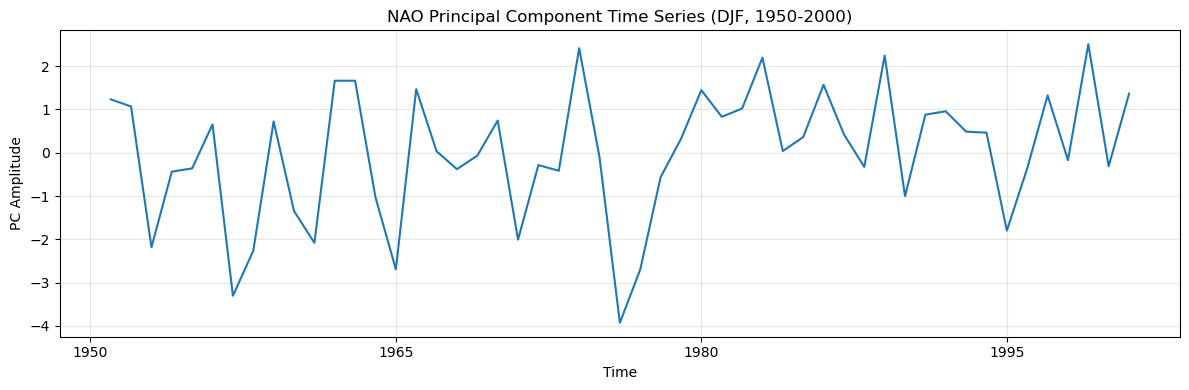

PC time series shape: (51,)
PC mean: 3.18e-16
PC std: 1.50


In [19]:
# Extract PC time series
pc_ts = nao_complete['DJF']['diagnostics']['pc_timeseries']

# Plot time series
fig, ax = plt.subplots(figsize=(12, 4))
pc_ts.plot(ax=ax)
ax.set_title('NAO Principal Component Time Series (DJF, 1950-2000)')
ax.set_xlabel('Time')
ax.set_ylabel('PC Amplitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PC time series shape: {pc_ts.shape}")
print(f"PC mean: {float(pc_ts.mean()):.2e}")
print(f"PC std: {float(pc_ts.std()):.2f}")

## Summary

This notebook demonstrated:

1. ✅ Basic variability mode computation (NAO, NAM)
2. ✅ With and without reference data (metrics)
3. ✅ **NEW: `remove_domain_mean` parameter** for detrending control
4. ✅ **NEW: `land_mask` parameter** for SST-based modes
5. ✅ **NEW: `landfrac_ds` parameter** for explicit land fraction data
6. ✅ SST-based modes (PDO, NPGO) with monthly analysis
7. ✅ Time subsetting
8. ✅ Different season options
9. ✅ Visualization of EOF patterns and PC time series

### Key Findings:
- The API successfully handles all variability modes
- `remove_domain_mean=True` (default) is recommended for focusing on spatial patterns
- `land_mask=True` is recommended for SST-based modes (PDO, NPGO, AMO)
- Both automatic and explicit land masking work correctly
- All computations complete successfully with realistic results